# Initial Model Development

This notebook evaluates simple regression models before moving to more complex approaches.

The same cleaned data, shared train-test split, engineered features, and reusable preprocessing functions from the previous stages are reused to maintain consistency and reproducibility.

Model selection will be based on training-set cross-validation rather than training performance alone. Preprocessing will be included inside each model pipeline to reduce data leakage during validation.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path

from sklearn.model_selection import KFold, cross_validate, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sys.path.append("..")

from src.data.cleaning import (
    clean_vehicle_data,
    create_shared_split
)

from src.features.engineering import (
    engineer_vehicle_features
)

from src.features.preprocessing import (
    create_linear_preprocessor,
    create_tree_preprocessor
)

from src.models.initial_models import (
    create_dummy_pipeline,
    create_linear_pipeline,
    create_ridge_pipeline,
    create_lasso_pipeline,
    create_decision_tree_pipeline,
    create_random_forest_pipeline
)

In [2]:
DATA_PATH = Path("../data/raw/car_price_dataset.csv")

df = pd.read_csv(DATA_PATH)

df_clean = clean_vehicle_data(df)

X_train, X_test, y_train, y_test = create_shared_split(df_clean)

X_train_engineered = engineer_vehicle_features(X_train)
X_test_engineered = engineer_vehicle_features(X_test)

print("X_train:", X_train_engineered.shape)
print("X_test:", X_test_engineered.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (7794, 15)
X_test: (1949, 15)
y_train: (7794,)
y_test: (1949,)


#### 1. Modelling Strategy and Evaluation

The initial models are compared using 5-fold cross-validation on the training data.

RMSE is used as the main comparison metric because larger vehicle-price errors should receive a greater penalty. MAE and R² are also reported for interpretation.

The test set remains untouched until the best initial model is selected.

In [3]:
# Create 5-fold cross-validation
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Metrics used for all models
scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2"
}

print(cv)

KFold(n_splits=5, random_state=42, shuffle=True)


#### 2. Dummy Baseline

A DummyRegressor is used as a simple reference baseline.
It predicts a constant value instead of learning relationships between features and vehicle price. The real regression models should perform better than this baseline.

In [4]:
# Create preprocessing + dummy model pipeline
dummy_pipeline = create_dummy_pipeline()

# Run 5-fold cross-validation
dummy_cv = cross_validate(
    dummy_pipeline,
    X_train_engineered,
    y_train,
    cv=cv,
    scoring=scoring
)

print("Dummy baseline completed.")

Dummy baseline completed.


In [5]:
# Convert negative scores back to positive errors
dummy_mae = -dummy_cv["test_mae"].mean()
dummy_rmse = -dummy_cv["test_rmse"].mean()
dummy_r2 = dummy_cv["test_r2"].mean()

# Display average cross-validation results
print("Dummy Baseline - 5-Fold CV")
print("MAE :", round(dummy_mae, 4))
print("RMSE:", round(dummy_rmse, 4))
print("R²  :", round(dummy_r2, 4))

Dummy Baseline - 5-Fold CV
MAE : 28.8059
RMSE: 43.0293
R²  : -0.0004


**Observation:** The DummyRegressor gave an RMSE of 43.0293 lakhs and an R² close to 0.
This provides a basic reference point for comparing the actual regression models.

#### 3. Linear Regression

Linear Regression is used as the first predictive baseline because it is simple and interpretable for a continuous target.

In [6]:
# Create preprocessing + Linear Regression pipeline
linear_pipeline = create_linear_pipeline()

# Run 5-fold cross-validation
linear_cv = cross_validate(
    linear_pipeline,
    X_train_engineered,
    y_train,
    cv=cv,
    scoring=scoring
)

print("Linear Regression completed.")

Linear Regression completed.


In [7]:
# Calculate average cross-validation results
linear_mae = -linear_cv["test_mae"].mean()
linear_rmse = -linear_cv["test_rmse"].mean()
linear_r2 = linear_cv["test_r2"].mean()

# Display results
print("Linear Regression - 5-Fold CV")
print("MAE :", round(linear_mae, 4))
print("RMSE:", round(linear_rmse, 4))
print("R²  :", round(linear_r2, 4))

Linear Regression - 5-Fold CV
MAE : 10.4418
RMSE: 22.0853
R²  : 0.7362


**Observation:** Linear Regression clearly outperformed the Dummy baseline.
The RMSE decreased from 43.0293 to 22.0853 lakhs, while R² increased to 0.7362, showing that the model explains a substantial amount of the variation in vehicle prices.

#### 4. Regularized Linear Models

Ridge and Lasso are tested to determine whether regularization improves the Linear Regression baseline.

#### 4.1 Ridge Regression

Ridge Regression is tested to see whether L2 regularization improves generalization by shrinking large coefficients.

In [8]:
# Create preprocessing + Ridge pipeline
ridge_pipeline = create_ridge_pipeline(alpha=1.0)

# Run 5-fold cross-validation
ridge_cv = cross_validate(
    ridge_pipeline,
    X_train_engineered,
    y_train,
    cv=cv,
    scoring=scoring
)

print("Ridge Regression completed.")

Ridge Regression completed.


In [9]:
# Calculate average cross-validation results
ridge_mae = -ridge_cv["test_mae"].mean()
ridge_rmse = -ridge_cv["test_rmse"].mean()
ridge_r2 = ridge_cv["test_r2"].mean()

# Display results
print("Ridge Regression - 5-Fold CV")
print("MAE :", round(ridge_mae, 4))
print("RMSE:", round(ridge_rmse, 4))
print("R²  :", round(ridge_r2, 4))

Ridge Regression - 5-Fold CV
MAE : 10.4221
RMSE: 22.0477
R²  : 0.7371


**Observation:** Ridge Regression performed slightly better than Linear Regression.
The improvement is small, suggesting that regularization helps a little but does not drastically change performance at alpha=1.0.

#### 4.2 Lasso Regression

Lasso Regression is tested to see whether L1 regularization can improve prediction while shrinking some coefficients toward zero.

In [10]:
# Create preprocessing + Lasso pipeline
lasso_pipeline = create_lasso_pipeline(alpha=0.1)

# Run 5-fold cross-validation
lasso_cv = cross_validate(
    lasso_pipeline,
    X_train_engineered,
    y_train,
    cv=cv,
    scoring=scoring
)

print("Lasso Regression completed.")

Lasso Regression completed.


In [11]:
# Calculate average cross-validation results
lasso_mae = -lasso_cv["test_mae"].mean()
lasso_rmse = -lasso_cv["test_rmse"].mean()
lasso_r2 = lasso_cv["test_r2"].mean()

# Display results
print("Lasso Regression - 5-Fold CV")
print("MAE :", round(lasso_mae, 4))
print("RMSE:", round(lasso_rmse, 4))
print("R²  :", round(lasso_r2, 4))

Lasso Regression - 5-Fold CV
MAE : 11.9833
RMSE: 23.3629
R²  : 0.7052


**Observation:** Lasso Regression performed worse than Linear Regression and Ridge at alpha=0.1.
This suggests that the current L1 regularization strength may be too strong or less suitable for this feature set.

#### 5. Regularization Selection

Ridge and Lasso alpha values are selected using cross-validation.

#### 5.1 Ridge Alpha Selection

Different Ridge alpha values are compared using the same 5-fold cross-validation.

In [12]:
# Alpha values to test
ridge_params = {
    "model__alpha": [0.01, 0.1, 1, 10, 100]
}

# Create Ridge pipeline
ridge_tuning_pipeline = create_ridge_pipeline()

# Search for the best alpha using RMSE
ridge_search = GridSearchCV(
    ridge_tuning_pipeline,
    ridge_params,
    cv=cv,
    scoring="neg_root_mean_squared_error"
)

# Run the search on training data only
ridge_search.fit(X_train_engineered, y_train)

print("Best alpha:", ridge_search.best_params_["model__alpha"])
print("Best CV RMSE:", round(-ridge_search.best_score_, 4))

Best alpha: 1
Best CV RMSE: 22.0477


**Observation:** The best Ridge alpha was 1.0, with a CV RMSE of 22.0477.
This confirms that the original Ridge setting was already suitable among the tested values.

#### 5.2 Lasso Alpha Selection

Different Lasso alpha values are compared using the same 5-fold cross-validation.

In [13]:
# Alpha values to test
lasso_params = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10]
}

# Create Lasso pipeline
lasso_tuning_pipeline = create_lasso_pipeline()

# Search for the best alpha using RMSE
lasso_search = GridSearchCV(
    lasso_tuning_pipeline,
    lasso_params,
    cv=cv,
    scoring="neg_root_mean_squared_error"
)

# Run the search on training data only
lasso_search.fit(X_train_engineered, y_train)

print("Best alpha:", lasso_search.best_params_["model__alpha"])
print("Best CV RMSE:", round(-lasso_search.best_score_, 4))

Best alpha: 0.01
Best CV RMSE: 22.0346


**Observation:** Ridge performed best at alpha=1.0 , while Lasso improved at alpha=0.01. The tuned Lasso produced the lowest RMSE among the linear models.

In [14]:
# Create tuned Ridge model
final_ridge = create_ridge_pipeline(alpha=1.0)

# Create tuned Lasso model
final_lasso = create_lasso_pipeline(alpha=0.01)

# Evaluate tuned Ridge
final_ridge_cv = cross_validate(
    final_ridge,
    X_train_engineered,
    y_train,
    cv=cv,
    scoring=scoring
)

# Evaluate tuned Lasso
final_lasso_cv = cross_validate(
    final_lasso,
    X_train_engineered,
    y_train,
    cv=cv,
    scoring=scoring
)

# Store tuned Ridge results
final_ridge_mae = -final_ridge_cv["test_mae"].mean()
final_ridge_rmse = -final_ridge_cv["test_rmse"].mean()
final_ridge_r2 = final_ridge_cv["test_r2"].mean()

# Store tuned Lasso results
final_lasso_mae = -final_lasso_cv["test_mae"].mean()
final_lasso_rmse = -final_lasso_cv["test_rmse"].mean()
final_lasso_r2 = final_lasso_cv["test_r2"].mean()

#### 6. Decision Tree Regression

A Decision Tree is tested as a non-linear model to capture pricing patterns that may not be handled well by the linear models.

max_depth=4 is used as a simple initial setting to limit tree complexity and reduce overfitting.

In [15]:
# Create preprocessing + Decision Tree pipeline
tree_pipeline = create_decision_tree_pipeline(max_depth=4)

# Run 5-fold cross-validation
tree_cv = cross_validate(
    tree_pipeline,
    X_train_engineered,
    y_train,
    cv=cv,
    scoring=scoring
)

print("Decision Tree completed.")

Decision Tree completed.


In [16]:
# Calculate average cross-validation results
tree_mae = -tree_cv["test_mae"].mean()
tree_rmse = -tree_cv["test_rmse"].mean()
tree_r2 = tree_cv["test_r2"].mean()

# Display results
print("Decision Tree - 5-Fold CV")
print("MAE :", round(tree_mae, 4))
print("RMSE:", round(tree_rmse, 4))
print("R²  :", round(tree_r2, 4))

Decision Tree - 5-Fold CV
MAE : 14.6271
RMSE: 27.5684
R²  : 0.5894


**Observation:** The Decision Tree with max_depth=4 performed worse than the linear models, so this shallow tree configuration did not improve prediction.

#### 7. Random Forest Regression

Random Forest is tested as an ensemble of decision trees to capture non-linear relationships more robustly than a single tree.

n_estimators=200 is used as a reasonable initial configuration for the model comparison.

In [17]:
# Create preprocessing + Random Forest pipeline
rf_pipeline = create_random_forest_pipeline(n_estimators=200)

# Run 5-fold cross-validation
rf_cv = cross_validate(
    rf_pipeline,
    X_train_engineered,
    y_train,
    cv=cv,
    scoring=scoring
)

print("Random Forest completed.")

Random Forest completed.


In [18]:
# Calculate average cross-validation results
rf_mae = -rf_cv["test_mae"].mean()
rf_rmse = -rf_cv["test_rmse"].mean()
rf_r2 = rf_cv["test_r2"].mean()

# Display results
print("Random Forest - 5-Fold CV")
print("MAE :", round(rf_mae, 4))
print("RMSE:", round(rf_rmse, 4))
print("R²  :", round(rf_r2, 4))

Random Forest - 5-Fold CV
MAE : 5.5095
RMSE: 15.7333
R²  : 0.8634


**Observation :** Random Forest achieved the best performance so far, with a cross-validation RMSE of 15.7333 lakhs and an R² of 0.8634.

It clearly outperformed the single Decision Tree and the linear models.

#### 8. Final Initial Model Comparison


In [19]:
# Create final comparison table
final_results = pd.DataFrame({
    "Model": [
        "DummyRegressor",
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        dummy_mae,
        linear_mae,
        final_ridge_mae,
        final_lasso_mae,
        tree_mae,
        rf_mae
    ],
    "RMSE": [
        dummy_rmse,
        linear_rmse,
        final_ridge_rmse,
        final_lasso_rmse,
        tree_rmse,
        rf_rmse
    ],
    "R2": [
        dummy_r2,
        linear_r2,
        final_ridge_r2,
        final_lasso_r2,
        tree_r2,
        rf_r2
    ]
})

# Sort by RMSE
final_results = final_results.sort_values("RMSE").reset_index(drop=True)

# Display results
final_results.round(4)

,Model,MAE,RMSE,R2
0,Random Forest,5.5095,15.7333,0.8634
1,Lasso Regression,10.3430,22.0346,0.7374
2,Ridge Regression,10.4221,22.0477,0.7371
3,Linear Regression,10.4418,22.0853,0.7362
4,Decision Tree,14.6271,27.5684,0.5894
5,DummyRegressor,28.8059,43.0293,-0.0004


**Observation :** Random Forest achieved the best cross-validation performance, with the lowest RMSE and highest R².
It clearly outperformed the single Decision Tree and the linear models, showing that an ensemble of trees captures the vehicle pricing patterns more effectively.

#### 9. Selected Initial Model

**Random Forest** is selected for final test evaluation because it achieved the best cross-validation performance among the tested initial models.

#### 10. Final Test Evaluation

Random Forest achieved the best cross-validation performance and is evaluated once on the untouched test set.

In [20]:
# Fit Random Forest on the full training set
rf_pipeline.fit(X_train_engineered, y_train)

# Predict the untouched test set
y_pred = rf_pipeline.predict(X_test_engineered)

# Calculate test metrics
test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = mean_squared_error(y_test, y_pred) ** 0.5
test_r2 = r2_score(y_test, y_pred)

# Display test results
print("Random Forest Test Results")
print("MAE :", round(test_mae, 4))
print("RMSE:", round(test_rmse, 4))
print("R²  :", round(test_r2, 4))

Random Forest Test Results
MAE : 6.0471
RMSE: 14.7322
R²  : 0.8954


**Observation :** Random Forest achieved an RMSE of 14.7322 lakhs and an R² of 0.8954 on the test set.

The test performance is consistent with the cross-validation result, suggesting good generalization to the held-out data.

#### 11. Residual Analysis

Residuals are checked to identify any systematic prediction errors in the final Random Forest model.

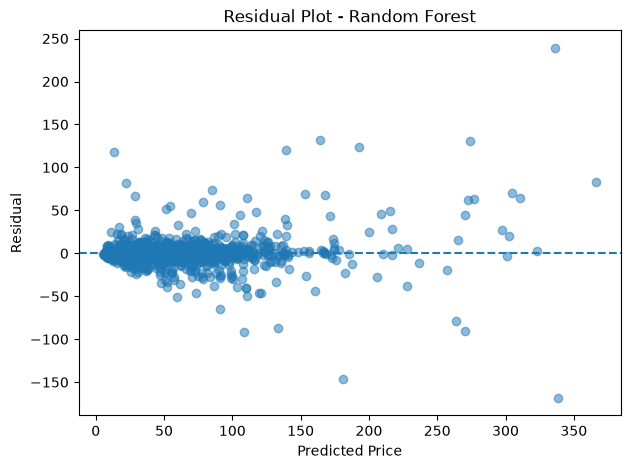

In [21]:
# Calculate residuals
residuals = y_test - y_pred

# Plot residuals against predicted values
plt.figure(figsize=(7, 5))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot - Random Forest")

plt.show()

**Observation :** Most residuals are concentrated around zero, suggesting that Random Forest predictions are generally accurate.

However, larger errors still appear for some high-priced vehicles.

#### 12. Actual vs Predicted Prices

Actual and predicted vehicle prices are compared to visually assess the final model.

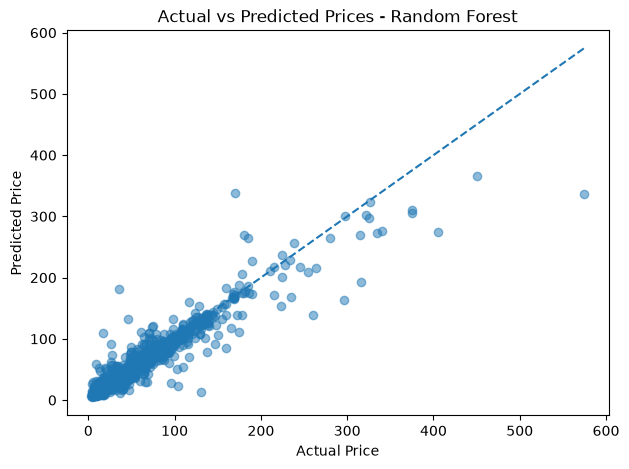

In [22]:
# Plot actual vs predicted prices
plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred, alpha=0.5)

# Perfect prediction reference line
min_price = min(y_test.min(), y_pred.min())
max_price = max(y_test.max(), y_pred.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices - Random Forest")

plt.show()

**Observation :** Most predictions are close to the ideal line, showing that Random Forest predicts vehicle prices well overall.
Some high-priced vehicles are still underpredicted.

#### 13. Limitations

The Random Forest performed well overall, but some larger prediction errors remain, especially for higher-priced vehicles.

The test MAE of 6.0471 lakhs means the average absolute prediction error is approximately LKR 604,710.

Because the data was split randomly, the test results mainly reflect performance on listings similar to the observed dataset and do not guarantee the same performance on future market conditions.

The target variable represents listed vehicle price, so the model predicts asking prices rather than confirmed final sale or trade-in prices.

#### 14. Initial Model Conclusion

Random Forest achieved the best cross-validation performance among the tested initial model configurations.

Its final test performance was:
- MAE: 6.0471 lakhs
- RMSE: 14.7322 lakhs
- R²: 0.8954

The diagnostic plots show generally accurate predictions, although larger errors remain for some high-priced vehicles.

Random Forest is therefore selected as the strongest initial model for further model improvement and tuning.